<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/LET'S_OVERFIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OVERFITTING

Source: https://github.com/lovnishverma/Python-Getting-Started/blob/main/Overfitting.ipynb

In [1]:
import pandas as pd

Create an Underfitting Model

**Dataset Used:** https://archive.ics.uci.edu/dataset/856/higher%2Beducation%2Bstudents%2Bperformance%2Bevaluation?utm_source=chatgpt.com



---



In [19]:
df = pd.read_csv("/content/DATA (1).csv")

In [20]:
df.head()

,STUDENT ID,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,...,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,...,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,...,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,...,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,...,2,1,2,2,2,1,2,2,1,1


In [27]:
# Drop STUDENT ID Column

df.drop('STUDENT ID', axis=1, inplace=True)

In [28]:
df['GRADE'].value_counts()

,count
GRADE,
1,35
2,24
3,21
5,17
7,17
6,13
4,10
0,8


In [29]:
df.describe()

,1,2,3,4,5,6,7,8,9,10,...,23,24,25,26,27,28,29,30,COURSE ID,GRADE
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,...,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,1.620690,1.600000,1.944828,3.572414,1.662069,1.600000,1.579310,1.627586,1.620690,1.731034,...,1.337931,1.165517,2.544828,2.055172,2.393103,1.806897,3.124138,2.724138,4.131034,3.227586
std,0.613154,0.491596,0.537216,0.805750,0.474644,0.491596,0.495381,1.020245,1.061112,0.783999,...,0.614870,0.408483,0.564940,0.674736,0.604343,0.810492,1.301083,0.916536,3.260145,2.197678
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,...,1.000000,1.000000,3.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,2.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,1.000000,3.000000,3.000000,3.000000,2.000000,4.000000,3.000000,7.000000,5.000000
max,3.000000,2.000000,3.000000,5.000000,2.000000,2.000000,2.000000,5.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,5.000000,4.000000,9.000000,7.000000


In [30]:
df.isnull().sum()

,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0
10,0


In [31]:
X = df.iloc[:,:-1] # Features
y = df.iloc[:,-1] # Target

In [32]:
# train-test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
# Model Evaluation on Train set (Training Set)

X_train_pred = model.predict(X_train)


# Get classification report

from sklearn.metrics import classification_report
print(classification_report(y_train, X_train_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.74      0.81      0.78        32
           2       0.73      0.80      0.76        20
           3       0.67      0.53      0.59        15
           4       0.71      0.71      0.71         7
           5       0.85      0.79      0.81        14
           6       0.88      0.78      0.82         9
           7       0.81      0.87      0.84        15

    accuracy                           0.77       116
   macro avg       0.80      0.76      0.77       116
weighted avg       0.77      0.77      0.77       116



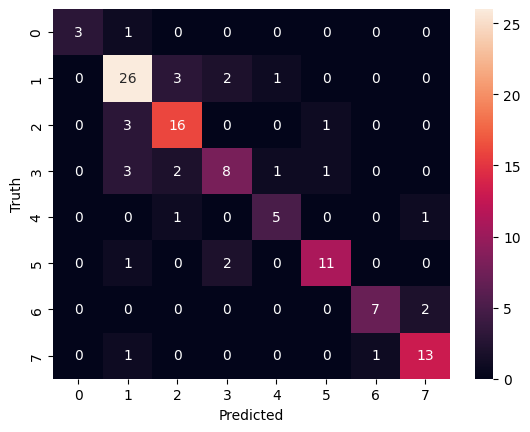

In [38]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train, X_train_pred)
import seaborn as sns
from matplotlib import pyplot as plt
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [35]:
# Model Evaluation on Test set (Test Set) / Unseen Data

y_pred = model.predict(X_test)


# Get classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.09      0.33      0.14         3
           2       0.00      0.00      0.00         4
           3       0.33      0.17      0.22         6
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.33      0.25      0.29         4
           7       0.00      0.00      0.00         2

    accuracy                           0.10        29
   macro avg       0.09      0.09      0.08        29
weighted avg       0.12      0.10      0.10        29



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


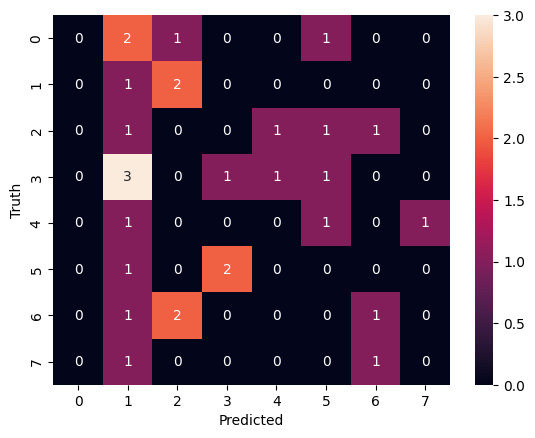

In [39]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
from matplotlib import pyplot as plt
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# Overfitting in Machine Learning

**Overfitting** occurs when a machine learning model learns the training data **too well**. Instead of learning the underlying patterns that generalize to new data, the model starts memorizing **noise, random variations, and minor quirks** present in the training dataset.

As a result, an overfitted model performs extremely well on the training data but performs poorly on **unseen data**.

> **In simple words:**
> The model memorizes the answers instead of learning the concepts.

For more details, see Google's [Machine Learning Crash Course — Overfitting](https://developers.google.com/machine-learning/crash-course/overfitting/overfitting).

---

## What Causes Overfitting?

### 1. High Model Complexity

A model with too many parameters, features, layers, or excessive flexibility has a high capacity to learn the training data — including its noise.

**Example:**

```text
Simple Model
     ↓
Learns important patterns
     ↓
Good Generalization


Highly Complex Model
     ↓
Learns patterns + noise
     ↓
Poor Generalization
```

---

### 2. Small Training Dataset

When the training dataset is too small, the model does not see enough examples to distinguish between:

* Genuine patterns
* Random correlations
* Noise

Therefore, the model may learn accidental relationships that do not exist in the real-world population.

---

### 3. Too Much Training

In iterative learning algorithms, excessive training can cause the model to gradually fit the training data more closely, including unusual or noisy observations.

This is particularly common in **neural networks**, where training for too many epochs can cause the model to memorize training-specific patterns.

---

# Signs of an Overfitted Model

## 1. High Training Accuracy

The model performs extremely well on the data used during training.

```text
Training Accuracy → Very High
Training Error    → Very Low
```

---

## 2. Poor Test Performance

When the same model is evaluated on **new, unseen data**, its performance drops significantly.

```text
Training Accuracy → 98%
Testing Accuracy  → 65%
```

A large gap between training and testing performance is a strong indication that the model may be overfitting.

---

## 3. High Variance

An overfitted model can be highly sensitive to changes in the training data.

Even a small change in the dataset may result in significantly different model parameters or predictions.

```text
Small Data Change
       ↓
Large Model Change
       ↓
Different Predictions
```

---

# How to Prevent Overfitting?

### 1. Simplify the Model

Reduce unnecessary model complexity.

For example:

* Reduce the number of features.
* Reduce the number of model parameters.
* Reduce polynomial degree.
* Use a simpler architecture.

---

### 2. Use Regularization

Regularization adds a penalty for overly large model coefficients.

Common techniques include:

* **L1 Regularization (Lasso)**
* **L2 Regularization (Ridge)**

For example, Logistic Regression commonly uses **L2 regularization by default in scikit-learn**.

The basic idea is:

```text
Model Error
     +
Complexity Penalty
     ↓
Better Generalization
```

---

### 3. Early Stopping

In iterative models such as neural networks, training can be stopped when performance on validation data stops improving.

```text
Training
   ↓
Validation Performance Improves
   ↓
Validation Performance Stops Improving
   ↓
STOP TRAINING
```

This prevents the model from continuing to fit training-specific noise.

---

### 4. Dropout

**Dropout** is commonly used with neural networks.

During training, randomly selected neurons are temporarily disabled. This prevents the network from relying too heavily on particular neurons and can improve generalization.

> **Note:** Dropout is primarily a neural-network technique and is **not used with standard Logistic Regression**.

---

### 5. Increase the Amount of Training Data

More representative training data gives the model more examples from which to learn the true underlying patterns.

```text
More Representative Data
          ↓
Better Pattern Learning
          ↓
Less Dependence on Noise
          ↓
Better Generalization
```

---

# Training vs Testing Performance

A useful way to identify overfitting is to compare training and testing performance.

| Model   | Training Accuracy | Testing Accuracy | Interpretation           |
| ------- | ----------------: | ---------------: | ------------------------ |
| Model A |               85% |              83% | Good Generalization      |
| Model B |               98% |              65% | ⚠️ Possible Overfitting  |
| Model C |               62% |              60% | ⚠️ Possible Underfitting |

### Key Idea

> **High training performance does not necessarily mean a good machine learning model.**

A good model should learn patterns that **generalize to previously unseen data**.

---

# Overfitting vs Underfitting

```text
                    MODEL COMPLEXITY
                          →
        Low                              High
         │                                │
         ▼                                ▼

    UNDERFITTING       GOOD FIT       OVERFITTING
         │                │                │
         ▼                ▼                ▼
    Too Simple       Learns Pattern    Too Complex
    Misses Pattern   Generalizes Well   Learns Noise
         │                │                │
    Train: Low        Train: Good      Train: Very High
    Test:  Low        Test:  Good      Test:  Low
```

---

# Important Takeaway

The goal of machine learning is **not to memorize the training data**.

The goal is to learn the underlying relationships in the data so that the model can make accurate predictions on **new, unseen observations**.

$$
\boxed{\text{Good Model} = \text{Good Performance on Unseen Data}}
$$

---

## References

1. [Google Machine Learning Crash Course — Overfitting](https://developers.google.com/machine-learning/crash-course/overfitting/overfitting)
2. [GeeksforGeeks — Underfitting and Overfitting](https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/)
3. [AWS — What is Overfitting?](https://aws.amazon.com/what-is/overfitting/)
4. [Ultralytics — Overfitting](https://www.ultralytics.com/glossary/overfitting)
5. [Wikipedia — Overfitting](https://en.wikipedia.org/wiki/Overfitting)
